# Step 1: Linear Isotherm Parameter Estimation Using Yamamoto Method 

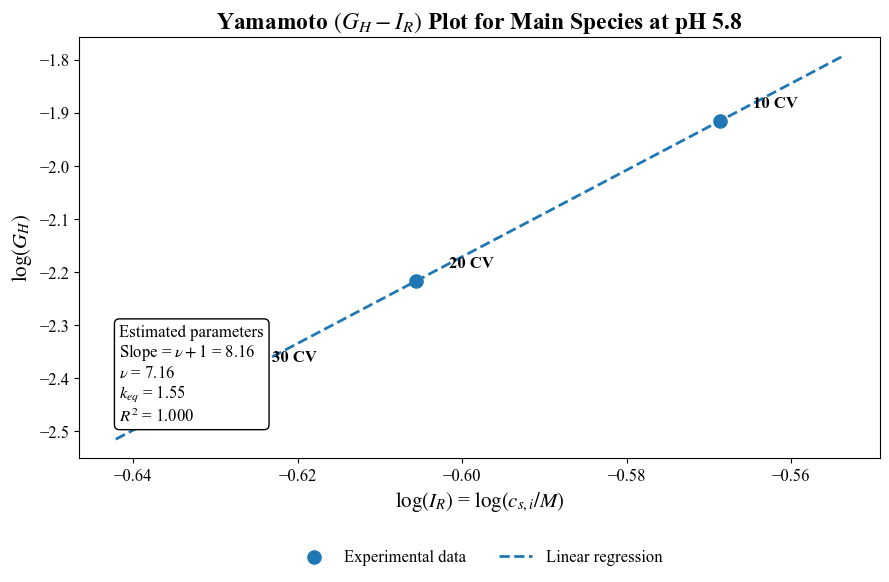

In [1]:
 import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# -----------------------------
# Representative Yamamoto data
# -----------------------------
gradient_cv = np.array([10, 20, 30])
GH = np.array([0.01215, 0.00608, 0.00405])
IR = np.array([0.270, 0.248, 0.236])   # elution salt concentration, M

log_GH = np.log10(GH)
log_IR = np.log10(IR)

# -----------------------------
# Linear regression
# log(GH) = slope*log(IR) + intercept
# slope = nu + 1
# -----------------------------
model = LinearRegression()
model.fit(log_IR.reshape(-1, 1), log_GH)

slope = model.coef_[0]
intercept = model.intercept_
r2 = model.score(log_IR.reshape(-1, 1), log_GH)

nu = slope - 1
Lambda = 0.292  # resin ionic capacity, M

keq = 10**(-intercept) / (Lambda**nu * (nu + 1))

# -----------------------------
# Plot formatting
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

fig, ax = plt.subplots(figsize=(9, 6))

# Data points
ax.scatter(
    log_IR,
    log_GH,
    s=90,
    marker="o",
    label="Experimental data"
)

# Regression line
xfit = np.linspace(log_IR.min() - 0.015, log_IR.max() + 0.015, 100)
yfit = slope * xfit + intercept

ax.plot(
    xfit,
    yfit,
    linestyle="--",
    linewidth=2,
    label="Linear regression"
)

# Label each point
for x, y, cv in zip(log_IR, log_GH, gradient_cv):
    ax.text(
        x + 0.004,
        y + 0.025,
        f"{cv} CV",
        fontsize=12,
        fontweight="bold"
    )

# Axis labels and title
ax.set_xlabel(r"$\log(I_R)$ = $\log(c_{s,i}/M)$", fontsize=15)
ax.set_ylabel(r"$\log(G_H)$", fontsize=15)

ax.set_title(
    r"Yamamoto $(G_H-I_R)$ Plot for Main Species at pH 5.8",
    fontsize=17,
    fontweight="bold"
)

# Parameter box moved to blank space below curve
parameter_text = (
    r"Estimated parameters" + "\n"
    rf"Slope = $\nu + 1$ = {slope:.2f}" + "\n"
    rf"$\nu$ = {nu:.2f}" + "\n"
    rf"$k_{{eq}}$ = {keq:.2f}" + "\n"
    rf"$R^2$ = {r2:.3f}"
)

ax.text(
    0.05,
    0.08,
    parameter_text,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round", facecolor="white", edgecolor="black")
)

# Legend at bottom, away from the curve
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    fontsize=12
)

ax.tick_params(axis="both", labelsize=12)

# No grid for PPT-clean formatting
ax.grid(False)

plt.tight_layout()

# Save high-resolution figure
plt.savefig("yamamoto_GH_IR_curve_TNR.png", dpi=300, bbox_inches="tight")
plt.savefig("yamamoto_GH_IR_curve_TNR.pdf", bbox_inches="tight")

plt.show()

# Step 2: Inverse Estimation of Nonlinear SMA Parameters

      kkin_fit   sigma_fit  kkin_published  sigma_published
APG   0.000009  129.428594        0.000008            128.6
Main  0.000094   56.718286        0.000100             56.3
BPG   0.000525  106.901154        0.000500            107.1


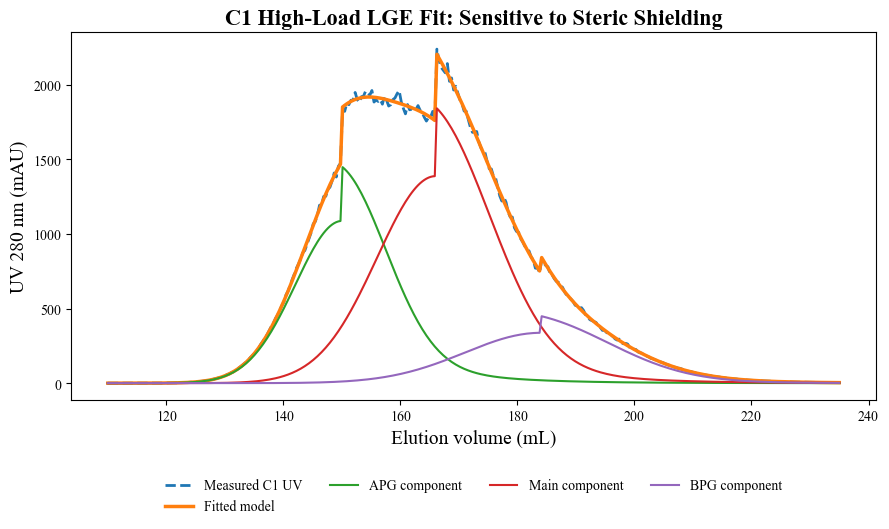

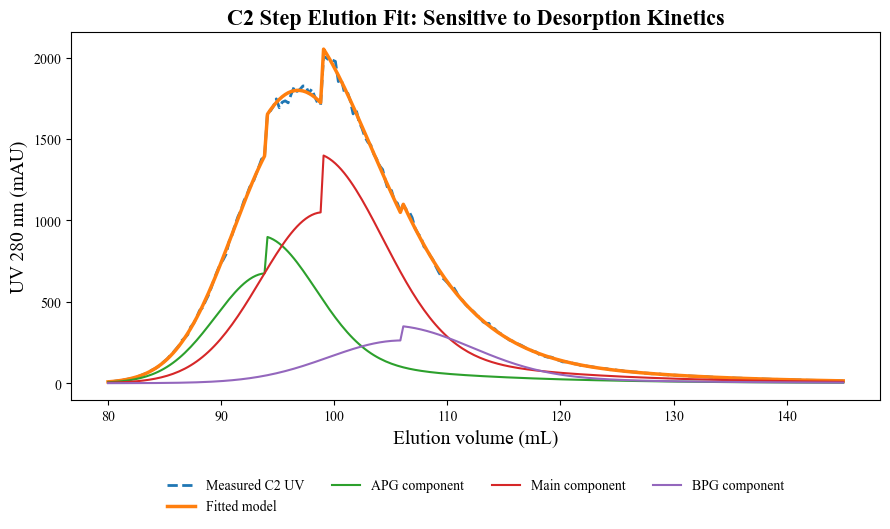

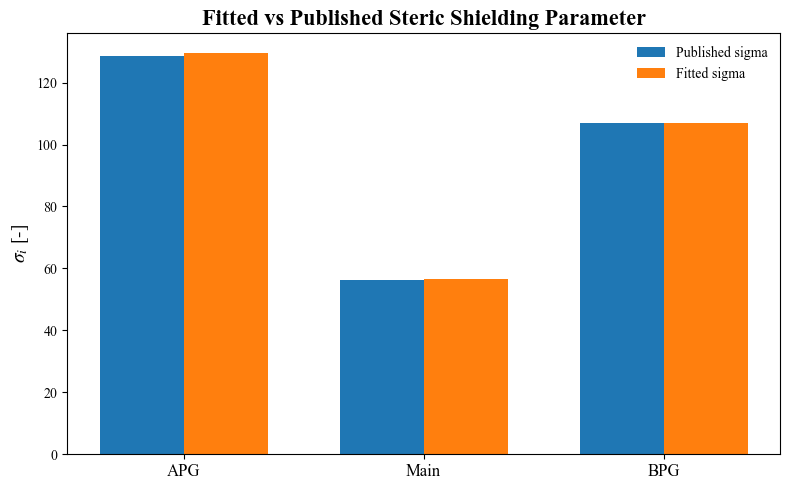

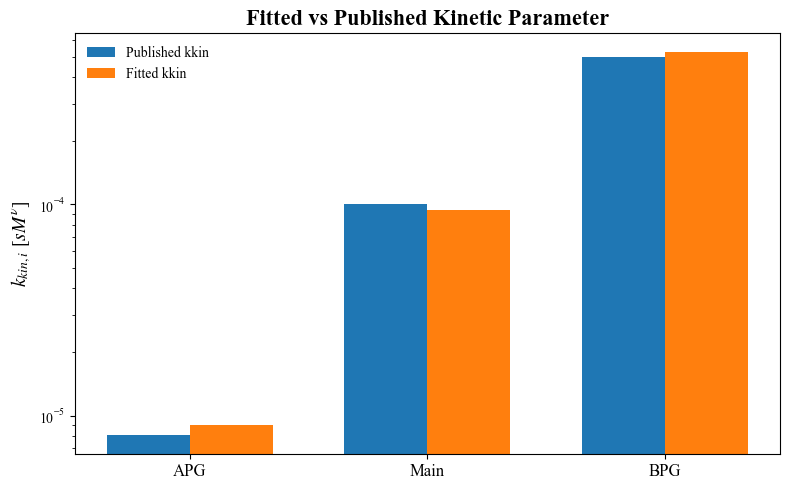

In [2]:
"""
Representative inverse estimation of nonlinear SMA parameters:
    kkin_i and sigma_i

This code demonstrates the logic used in Saleh et al.:
1. Use fixed nu_i and keq_i from Yamamoto analysis.
2. Use C1 high-load LGE + C2 step elution chromatograms.
3. Fit remaining nonlinear parameters kkin_i and sigma_i by least squares.

Important:
- This is a representative educational implementation.
- It is not a full ChromX/CADET transport-dispersive PDE solver.
- Replace the synthetic data with digitized C1/C2 chromatogram CSV files
  to use your own experimental data.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from pathlib import Path

# -----------------------------
# 1. Published fixed parameters
# -----------------------------
species = ["APG", "Main", "BPG"]

nu = {
    "APG": 7.38,
    "Main": 7.50,
    "BPG": 7.70,
}

keq = {
    "APG": 1.45,
    "Main": 1.41,
    "BPG": 1.69,
}

# Published final values at pH 5.8, used here to generate demo data
true_params = {
    "APG": {"kkin": 8.08e-6, "sigma": 128.6},
    "Main": {"kkin": 1.00e-4, "sigma": 56.3},
    "BPG": {"kkin": 5.00e-4, "sigma": 107.1},
}

# -----------------------------
# 2. Representative peak model
# -----------------------------
def skewed_peak(volume, center, width, area, tail):
    """
    Simple skewed peak function.
    This is a surrogate for chromatographic peak shape.

    center: retention volume
    width: peak width
    area: peak intensity
    tail: tailing factor
    """
    gaussian = np.exp(-0.5 * ((volume - center) / width) ** 2)

    tail_part = np.exp(-(volume - center) / tail)
    tail_part[volume < center] = 0

    peak = 0.75 * gaussian + 0.25 * tail_part
    return area * peak


def simulate_experiment(volume, params_vector, experiment="C1"):
    """
    Simulates UV chromatogram from kkin and sigma values.

    params_vector:
        [log10(kkin_APG), sigma_APG,
         log10(kkin_Main), sigma_Main,
         log10(kkin_BPG), sigma_BPG]
    """

    p = {}
    for i, sp in enumerate(species):
        p[sp] = {
            "kkin": 10 ** params_vector[2 * i],
            "sigma": params_vector[2 * i + 1],
        }

    signal_total = np.zeros_like(volume)
    components = {}

    for sp in species:
        kkin_i = p[sp]["kkin"]
        sigma_i = p[sp]["sigma"]

        # Retention affected by binding strength and shielding
        # Larger sigma gives stronger nonlinear shift in overloaded LGE.
        base_center = {"APG": 150, "Main": 166, "BPG": 184}[sp]

        if experiment == "C1":
            # High-load LGE: more sensitive to sigma
            center = base_center + 0.045 * (sigma_i - true_params[sp]["sigma"])
            width = {"APG": 8, "Main": 10, "BPG": 13}[sp]
            area = {"APG": 1450, "Main": 1850, "BPG": 450}[sp]

        elif experiment == "C2":
            # Step elution: less sigma-sensitive
            center = {"APG": 94, "Main": 99, "BPG": 106}[sp]
            center = center + 0.010 * (sigma_i - true_params[sp]["sigma"])
            width = {"APG": 4.5, "Main": 5.5, "BPG": 6.5}[sp]
            area = {"APG": 900, "Main": 1400, "BPG": 350}[sp]

        else:
            raise ValueError("experiment must be 'C1' or 'C2'")

        # kkin controls peak tailing
        # smaller kkin = larger tailing
        k_ref = true_params[sp]["kkin"]
        tail = 12 * (k_ref / kkin_i) ** 0.35
        tail = np.clip(tail, 4, 45)

        comp = skewed_peak(volume, center, width, area, tail)
        components[sp] = comp
        signal_total += comp

    # UV detector saturation in the paper was 3000 mAU
    signal_total = np.minimum(signal_total, 3000)

    return signal_total, components


# -----------------------------
# 3. Load or generate data
# -----------------------------
def make_demo_data():
    rng = np.random.default_rng(42)

    vol_C1 = np.linspace(110, 235, 350)
    vol_C2 = np.linspace(80, 145, 250)

    p_true = []
    for sp in species:
        p_true.extend([
            np.log10(true_params[sp]["kkin"]),
            true_params[sp]["sigma"]
        ])
    p_true = np.array(p_true)

    uv_C1, comp_C1 = simulate_experiment(vol_C1, p_true, "C1")
    uv_C2, comp_C2 = simulate_experiment(vol_C2, p_true, "C2")

    uv_C1_meas = uv_C1 * (1 + rng.normal(0, 0.015, size=uv_C1.size))
    uv_C2_meas = uv_C2 * (1 + rng.normal(0, 0.015, size=uv_C2.size))

    return vol_C1, uv_C1_meas, vol_C2, uv_C2_meas


# Use this if you digitize Figure 2 manually:
# C1_csv = pd.read_csv("C1_digitized.csv")  # columns: volume_mL, uv_mAU
# C2_csv = pd.read_csv("C2_digitized.csv")  # columns: volume_mL, uv_mAU
# vol_C1, uv_C1_meas = C1_csv["volume_mL"].values, C1_csv["uv_mAU"].values
# vol_C2, uv_C2_meas = C2_csv["volume_mL"].values, C2_csv["uv_mAU"].values

vol_C1, uv_C1_meas, vol_C2, uv_C2_meas = make_demo_data()

# -----------------------------
# 4. Least-squares objective
# -----------------------------
def residuals(params_vector):
    pred_C1, _ = simulate_experiment(vol_C1, params_vector, "C1")
    pred_C2, _ = simulate_experiment(vol_C2, params_vector, "C2")

    # Normalize residuals so C1 and C2 contribute similarly
    r1 = (pred_C1 - uv_C1_meas) / np.max(uv_C1_meas)
    r2 = (pred_C2 - uv_C2_meas) / np.max(uv_C2_meas)

    return np.concatenate([r1, r2])


# -----------------------------
# 5. Initial guesses and bounds
# -----------------------------
# Guess values intentionally not equal to published values
x0 = np.array([
    np.log10(2e-5), 80,     # APG
    np.log10(5e-5), 80,     # Main
    np.log10(2e-4), 80,     # BPG
])

lower = np.array([
    -7.0, 0,
    -7.0, 0,
    -7.0, 0,
])

upper = np.array([
    -2.5, 200,
    -2.5, 200,
    -2.5, 200,
])

fit = least_squares(
    residuals,
    x0,
    bounds=(lower, upper),
    method="trf",
    max_nfev=5000
)

# -----------------------------
# 6. Extract fitted parameters
# -----------------------------
fitted = {}
for i, sp in enumerate(species):
    fitted[sp] = {
        "kkin_fit": 10 ** fit.x[2 * i],
        "sigma_fit": fit.x[2 * i + 1],
        "kkin_published": true_params[sp]["kkin"],
        "sigma_published": true_params[sp]["sigma"],
    }

results = pd.DataFrame(fitted).T
print(results)

# -----------------------------
# 7. Plot fits
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

outdir = Path("inverse_estimation_outputs")
outdir.mkdir(exist_ok=True)

pred_C1, comp_C1 = simulate_experiment(vol_C1, fit.x, "C1")
pred_C2, comp_C2 = simulate_experiment(vol_C2, fit.x, "C2")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(vol_C1, uv_C1_meas, "--", linewidth=2, label="Measured C1 UV")
ax.plot(vol_C1, pred_C1, linewidth=2.5, label="Fitted model")
for sp in species:
    ax.plot(vol_C1, comp_C1[sp], linewidth=1.5, label=f"{sp} component")

ax.set_title("C1 High-Load LGE Fit: Sensitive to Steric Shielding", fontsize=16, fontweight="bold")
ax.set_xlabel("Elution volume (mL)", fontsize=14)
ax.set_ylabel("UV 280 nm (mAU)", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(outdir / "C1_inverse_fit.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(vol_C2, uv_C2_meas, "--", linewidth=2, label="Measured C2 UV")
ax.plot(vol_C2, pred_C2, linewidth=2.5, label="Fitted model")
for sp in species:
    ax.plot(vol_C2, comp_C2[sp], linewidth=1.5, label=f"{sp} component")

ax.set_title("C2 Step Elution Fit: Sensitive to Desorption Kinetics", fontsize=16, fontweight="bold")
ax.set_xlabel("Elution volume (mL)", fontsize=14)
ax.set_ylabel("UV 280 nm (mAU)", fontsize=14)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
ax.grid(False)
plt.tight_layout()
plt.savefig(outdir / "C2_inverse_fit.png", dpi=300, bbox_inches="tight")
plt.show()

# -----------------------------
# 8. Parameter comparison plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(species))
width = 0.35

ax.bar(x - width/2, results["sigma_published"], width, label="Published sigma")
ax.bar(x + width/2, results["sigma_fit"], width, label="Fitted sigma")

ax.set_xticks(x)
ax.set_xticklabels(species, fontsize=12)
ax.set_ylabel(r"$\sigma_i$ [-]", fontsize=14)
ax.set_title("Fitted vs Published Steric Shielding Parameter", fontsize=16, fontweight="bold")
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
plt.savefig(outdir / "sigma_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width/2, results["kkin_published"], width, label="Published kkin")
ax.bar(x + width/2, results["kkin_fit"], width, label="Fitted kkin")

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(species, fontsize=12)
ax.set_ylabel(r"$k_{kin,i}$ [$sM^\nu$]", fontsize=14)
ax.set_title("Fitted vs Published Kinetic Parameter", fontsize=16, fontweight="bold")
ax.legend(frameon=False)
ax.grid(False)

plt.tight_layout()
plt.savefig(outdir / "kkin_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

## Step 3: pH-Dependent SMA Model


Calculated pH-dependent SMA parameters:
   Species   pH  pH_norm    nu_i   keq_i
0      APG  5.5     -0.3   7.812   6.339
1      APG  5.8      0.0   7.380   1.450
2      APG  6.1      0.3   6.948   0.492
3     Main  5.5     -0.3   7.932   6.164
4     Main  5.8      0.0   7.500   1.410
5     Main  6.1      0.3   7.068   0.478
6      BPG  5.5     -0.3   8.132   7.388
7      BPG  5.8      0.0   7.700   1.690
8      BPG  6.1      0.3   7.268   0.573
9      HMW  5.5     -0.3  13.001  15.497
10     HMW  5.8      0.0  10.970   1.860
11     HMW  6.1      0.3   8.939   0.611


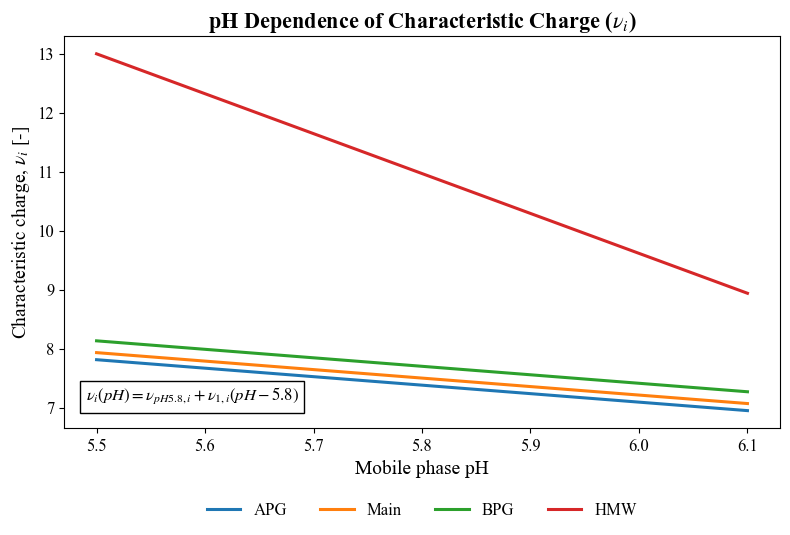

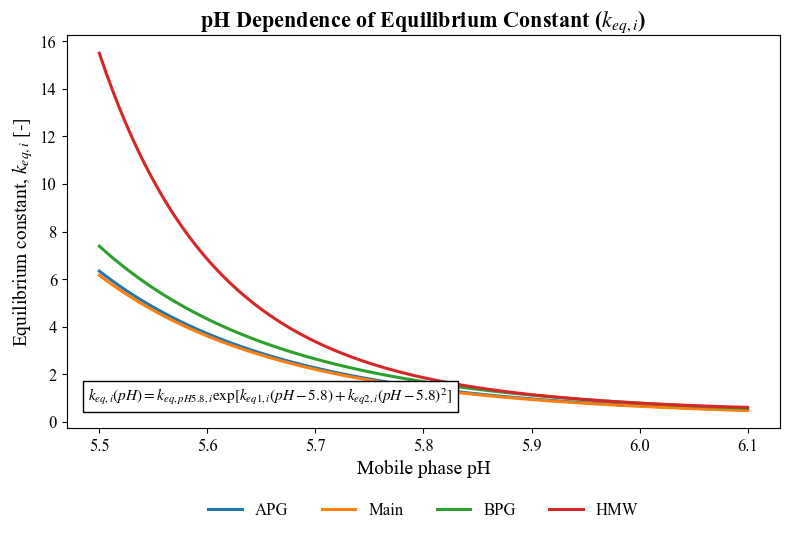


Files saved:
pH_dependent_SMA_nu_i.png
pH_dependent_SMA_keq_i.png
pH_dependent_SMA_full_range.csv
pH_dependent_SMA_summary_values.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Step 3: pH-dependent SMA model
# Data from Saleh et al., Table 4
# "Straightforward method for calibration of mechanistic
# cation exchange chromatography models for industrial applications"
# ============================================================

# ------------------------------------------------------------
# 1. Input pH-dependent SMA parameters from the paper
# ------------------------------------------------------------
data = {
    "Species": ["APG", "Main", "BPG", "HMW"],

    # Characteristic charge at pH 5.8
    "nu_pH58": [7.38, 7.50, 7.70, 10.97],

    # Linear pH dependency of characteristic charge
    "nu_1": [-1.44, -1.44, -1.44, -6.77],

    # Equilibrium constant at pH 5.8
    "keq_pH58": [1.45, 1.41, 1.69, 1.86],

    # pH dependency of equilibrium constant
    "keq_1": [-4.26, -4.26, -4.26, -5.39],
    "keq_2": [2.19, 2.19, 2.19, 5.59],
}

df_params = pd.DataFrame(data)

# ------------------------------------------------------------
# 2. Define pH-dependent equations
# Paper normalizes pH around pH 5.8:
# pH_norm = pH_actual - 5.8
# ------------------------------------------------------------
def calculate_nu(pH_actual, nu_pH58, nu_1):
    """
    pH-dependent characteristic charge.
    """
    pH_norm = pH_actual - 5.8
    return nu_pH58 + nu_1 * pH_norm


def calculate_keq(pH_actual, keq_pH58, keq_1, keq_2):
    """
    pH-dependent equilibrium constant.
    """
    pH_norm = pH_actual - 5.8
    return keq_pH58 * np.exp(keq_1 * pH_norm + keq_2 * pH_norm**2)


# ------------------------------------------------------------
# 3. Calculate values across process-relevant pH range
# ------------------------------------------------------------
pH_range = np.linspace(5.5, 6.1, 100)

results = []

for _, row in df_params.iterrows():
    for pH in pH_range:
        nu_value = calculate_nu(
            pH,
            row["nu_pH58"],
            row["nu_1"]
        )

        keq_value = calculate_keq(
            pH,
            row["keq_pH58"],
            row["keq_1"],
            row["keq_2"]
        )

        results.append({
            "Species": row["Species"],
            "pH": pH,
            "pH_norm": pH - 5.8,
            "nu_i": nu_value,
            "keq_i": keq_value
        })

df_results = pd.DataFrame(results)

# ------------------------------------------------------------
# 4. Print calculated values at pH 5.5, 5.8, and 6.1
# ------------------------------------------------------------
summary_rows = []

for _, row in df_params.iterrows():
    for pH in [5.5, 5.8, 6.1]:
        summary_rows.append({
            "Species": row["Species"],
            "pH": pH,
            "pH_norm": pH - 5.8,
            "nu_i": calculate_nu(pH, row["nu_pH58"], row["nu_1"]),
            "keq_i": calculate_keq(pH, row["keq_pH58"], row["keq_1"], row["keq_2"])
        })

df_summary = pd.DataFrame(summary_rows)

print("\nCalculated pH-dependent SMA parameters:")
print(df_summary.round(3))

# ------------------------------------------------------------
# 5. Plot pH effect on characteristic charge nu_i
# ------------------------------------------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

fig, ax = plt.subplots(figsize=(8, 5.5))

for species in df_params["Species"]:
    temp = df_results[df_results["Species"] == species]
    ax.plot(
        temp["pH"],
        temp["nu_i"],
        linewidth=2.2,
        label=species
    )

ax.set_title(
    r"pH Dependence of Characteristic Charge ($\nu_i$)",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Mobile phase pH", fontsize=14)
ax.set_ylabel(r"Characteristic charge, $\nu_i$ [-]", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    fontsize=12
)

ax.text(
    0.03,
    0.07,
    r"$\nu_i(pH)=\nu_{pH5.8,i}+\nu_{1,i}(pH-5.8)$",
    transform=ax.transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", edgecolor="black")
)

plt.tight_layout()
plt.savefig("pH_dependent_SMA_nu_i.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Plot pH effect on equilibrium constant keq_i
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))

for species in df_params["Species"]:
    temp = df_results[df_results["Species"] == species]
    ax.plot(
        temp["pH"],
        temp["keq_i"],
        linewidth=2.2,
        label=species
    )

ax.set_title(
    r"pH Dependence of Equilibrium Constant ($k_{eq,i}$)",
    fontsize=16,
    fontweight="bold"
)
ax.set_xlabel("Mobile phase pH", fontsize=14)
ax.set_ylabel(r"Equilibrium constant, $k_{eq,i}$ [-]", fontsize=14)
ax.tick_params(axis="both", labelsize=12)
ax.grid(False)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False,
    fontsize=12
)

ax.text(
    0.03,
    0.07,
    r"$k_{eq,i}(pH)=k_{eq,pH5.8,i}\exp[k_{eq1,i}(pH-5.8)+k_{eq2,i}(pH-5.8)^2]$",
    transform=ax.transAxes,
    fontsize=11,
    bbox=dict(facecolor="white", edgecolor="black")
)

plt.tight_layout()
plt.savefig("pH_dependent_SMA_keq_i.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 7. Export calculated values
# ------------------------------------------------------------
df_results.to_csv("pH_dependent_SMA_full_range.csv", index=False)
df_summary.to_csv("pH_dependent_SMA_summary_values.csv", index=False)

print("\nFiles saved:")
print("pH_dependent_SMA_nu_i.png")
print("pH_dependent_SMA_keq_i.png")
print("pH_dependent_SMA_full_range.csv")
print("pH_dependent_SMA_summary_values.csv")

## Validation
The model combined:

Transport-dispersive column model for convection, axial dispersion, and mass transfer.
Lumped-rate pore model where film/pore transport effects are combined into keff,i
Multicomponent SMA adsorption isotherm for competitive ion-exchange binding.
pH-dependent νi and keq,i to predict behavior at pH 5.5, 5.8, and 6.1.
Validation data V1–V12 from Table 1, including LGE and step-elution experiments at low, moderate, and high load.

The authors used ChromX for the actual simulations and inverse parameter estimation. The raw chromatogram data are not provided in the paper, so the code below is a representative mechanistic implementation using the model equations and parameters reported in the paper.

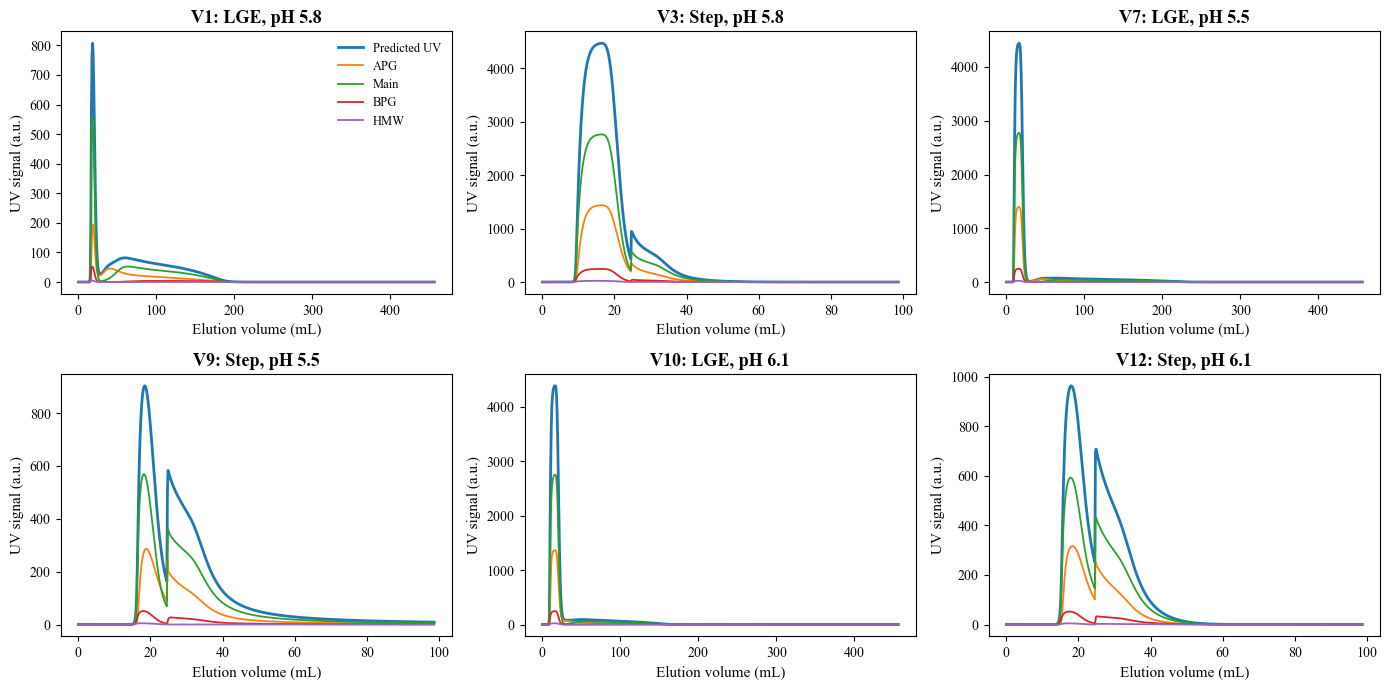

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# pH-dependent mechanistic CEX model
# Representative implementation based on Saleh et al.
# Transport-dispersive model + lumped-rate pore model + SMA
# ============================================================

# -----------------------------
# 1. Column/system parameters
# -----------------------------
L = 157.0          # column length, mm
rp = 25e-3         # bead radius, mm
eps_col = 0.41     # interstitial porosity
eps_p = 0.53       # particle porosity
Lambda = 0.292     # ionic capacity, M
Dax = 0.17         # axial dispersion, mm^2/s

# Flow rate from paper: 0.22 mL/min, 10 mm ID column
# Convert to superficial velocity approximately
diameter_mm = 10
area_mm2 = np.pi * (diameter_mm / 2)**2
flow_mL_min = 0.22
flow_mm3_s = flow_mL_min * 1000 / 60
u = flow_mm3_s / area_mm2   # mm/s

# -----------------------------
# 2. Species parameters
# -----------------------------
species = ["APG", "Main", "BPG", "HMW"]

params = {
    "APG":  {"nu58": 7.38,  "nu1": -1.44, "keq58": 1.45, "keq1": -4.26, "keq2": 2.19,
             "kkin": 8.08e-6, "sigma": 128.6, "keff": 0.00147},
    "Main": {"nu58": 7.50,  "nu1": -1.44, "keq58": 1.41, "keq1": -4.26, "keq2": 2.19,
             "kkin": 1.00e-4, "sigma": 56.3,  "keff": 0.00147},
    "BPG":  {"nu58": 7.70,  "nu1": -1.44, "keq58": 1.69, "keq1": -4.26, "keq2": 2.19,
             "kkin": 5.00e-4, "sigma": 107.1, "keff": 0.00147},
    "HMW":  {"nu58": 10.97, "nu1": -6.77, "keq58": 1.86, "keq1": -5.39, "keq2": 5.59,
             "kkin": 3.40e-5, "sigma": 0.0,   "keff": 0.00117},
}

def nu_pH(sp, pH):
    pHn = pH - 5.8
    return params[sp]["nu58"] + params[sp]["nu1"] * pHn

def keq_pH(sp, pH):
    pHn = pH - 5.8
    return params[sp]["keq58"] * np.exp(
        params[sp]["keq1"] * pHn + params[sp]["keq2"] * pHn**2
    )

# -----------------------------
# 3. Validation experiments V1–V12 from Table 1
# -----------------------------
experiments = {
    "V1":  {"mode": "LGE",  "pH": 5.8, "eq_salt": 50, "load_salt": 82, "elution": (50, 500), "gradient_CV": 30, "load_density": 10},
    "V2":  {"mode": "LGE",  "pH": 5.8, "eq_salt": 50, "load_salt": 82, "elution": (50, 500), "gradient_CV": 50, "load_density": 10},
    "V3":  {"mode": "Step", "pH": 5.8, "eq_salt": 87, "load_salt": 90, "elution": 247,       "gradient_CV": None, "load_density": 45},
    "V4":  {"mode": "Step", "pH": 5.8, "eq_salt": 87, "load_salt": 90, "elution": 277,       "gradient_CV": None, "load_density": 10},
    "V5":  {"mode": "LGE",  "pH": 5.8, "eq_salt": 50, "load_salt": 82, "elution": (50, 500), "gradient_CV": 15, "load_density": 1},
    "V6":  {"mode": "LGE",  "pH": 5.8, "eq_salt": 50, "load_salt": 82, "elution": (50, 500), "gradient_CV": 25, "load_density": 1},
    "V7":  {"mode": "LGE",  "pH": 5.5, "eq_salt": 50, "load_salt": 82, "elution": (50, 500), "gradient_CV": 30, "load_density": 45},
    "V8":  {"mode": "Step", "pH": 5.5, "eq_salt": 87, "load_salt": 82, "elution": 247,       "gradient_CV": None, "load_density": 10},
    "V9":  {"mode": "Step", "pH": 5.5, "eq_salt": 87, "load_salt": 82, "elution": 217,       "gradient_CV": None, "load_density": 10},
    "V10": {"mode": "LGE",  "pH": 6.1, "eq_salt": 50, "load_salt": 82, "elution": (50, 500), "gradient_CV": 30, "load_density": 45},
    "V11": {"mode": "Step", "pH": 6.1, "eq_salt": 87, "load_salt": 82, "elution": 247,       "gradient_CV": None, "load_density": 10},
    "V12": {"mode": "Step", "pH": 6.1, "eq_salt": 87, "load_salt": 82, "elution": 217,       "gradient_CV": None, "load_density": 10},
}

# -----------------------------
# 4. Inlet profile
# -----------------------------
CV_time = L / u   # approximate one-column-volume residence time, s

def inlet_salt(t, exp):
    """Salt concentration at inlet, M."""
    load_end = 1.0 * CV_time
    wash_end = 2.0 * CV_time

    if t < load_end:
        return exp["load_salt"] / 1000
    elif t < wash_end:
        return exp["eq_salt"] / 1000
    else:
        if exp["mode"] == "Step":
            return exp["elution"] / 1000
        else:
            c0, c1 = exp["elution"]
            grad_time = exp["gradient_CV"] * CV_time
            frac = min((t - wash_end) / grad_time, 1.0)
            return (c0 + frac * (c1 - c0)) / 1000

def inlet_protein(t, exp):
    """Representative protein feed pulse; concentration scaled by load density."""
    load_end = 1.0 * CV_time

    if t > load_end:
        return np.zeros(len(species))

    # Representative feed composition
    feed_frac = np.array([0.32, 0.62, 0.055, 0.005])

    # Scale concentration with loading density
    total_conc = 0.001 * exp["load_density"] / 10
    return total_conc * feed_frac

# -----------------------------
# 5. Mechanistic ODE system
# -----------------------------
def simulate(exp_name, N=50):
    exp = experiments[exp_name]
    dx = L / N
    nsp = len(species)

    # State variables:
    # c_mobile: N x species
    # c_pore:   N x species
    # q_bound:  N x species
    n_state = N * nsp * 3

    y0 = np.zeros(n_state)

    def unpack(y):
        c = y[0:N*nsp].reshape(N, nsp)
        cp = y[N*nsp:2*N*nsp].reshape(N, nsp)
        q = y[2*N*nsp:3*N*nsp].reshape(N, nsp)
        return c, cp, q

    def rhs(t, y):
        c, cp, q = unpack(y)

        dc_dt = np.zeros_like(c)
        dcp_dt = np.zeros_like(cp)
        dq_dt = np.zeros_like(q)

        salt = inlet_salt(t, exp)
        c_in = inlet_protein(t, exp)

        for j, sp in enumerate(species):
            keff = params[sp]["keff"]

            # Axial convection/dispersion finite difference
            for k in range(N):
                if k == 0:
                    c_left = c_in[j]
                    c_right = c[k+1, j]
                elif k == N - 1:
                    c_left = c[k-1, j]
                    c_right = c[k, j]
                else:
                    c_left = c[k-1, j]
                    c_right = c[k+1, j]

                convection = -u / eps_col * (c[k, j] - c_left) / dx
                dispersion = Dax * (c_right - 2*c[k, j] + c_left) / dx**2

                mass_transfer = -((1 - eps_col) / eps_col) * (3 / rp) * keff * (c[k, j] - cp[k, j])

                dc_dt[k, j] = convection + dispersion + mass_transfer

        # SMA adsorption kinetics
        for k in range(N):
            free_capacity = Lambda
            for j, sp in enumerate(species):
                free_capacity -= (nu_pH(sp, exp["pH"]) + params[sp]["sigma"]) * q[k, j]

            free_capacity = max(free_capacity, 1e-12)

            for j, sp in enumerate(species):
                nu = nu_pH(sp, exp["pH"])
                keq = keq_pH(sp, exp["pH"])
                kkin = params[sp]["kkin"]
                keff = params[sp]["keff"]

                adsorption_term = keq * (free_capacity ** nu) * cp[k, j]
                desorption_term = q[k, j] * (salt ** nu)

                dq_dt[k, j] = (adsorption_term - desorption_term) / kkin

                dcp_dt[k, j] = (
                    (3 / rp) * keff / eps_p * (c[k, j] - cp[k, j])
                    - ((1 - eps_p) / eps_p) * dq_dt[k, j]
                )

        return np.concatenate([dc_dt.ravel(), dcp_dt.ravel(), dq_dt.ravel()])

    # Simulation time
    if exp["mode"] == "LGE":
        t_end = (2 + exp["gradient_CV"] + 5) * CV_time
    else:
        t_end = 8 * CV_time

    t_eval = np.linspace(0, t_end, 600)

    sol = solve_ivp(
        rhs,
        [0, t_end],
        y0,
        method="BDF",
        t_eval=t_eval,
        rtol=1e-5,
        atol=1e-8
    )

    c, cp, q = unpack(sol.y[:, -1])

    outlet = []
    for idx in range(sol.y.shape[1]):
        c_tmp, _, _ = unpack(sol.y[:, idx])
        outlet.append(c_tmp[-1, :])

    outlet = np.array(outlet)

    # Convert concentration to representative UV signal
    uv_components = outlet * np.array([1.0, 1.0, 1.0, 1.0]) * 1e6
    uv_total = uv_components.sum(axis=1)

    volume_mL = sol.t / CV_time * 12.33

    return volume_mL, uv_total, uv_components

# -----------------------------
# 6. Run and plot validation experiments
# -----------------------------
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["mathtext.fontset"] = "stix"

selected = ["V1", "V3", "V7", "V9", "V10", "V12"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.ravel()

for ax, exp_name in zip(axes, selected):
    volume, uv, comps = simulate(exp_name, N=35)

    ax.plot(volume, uv, linewidth=2, label="Predicted UV")
    ax.plot(volume, comps[:, 0], linewidth=1.3, label="APG")
    ax.plot(volume, comps[:, 1], linewidth=1.3, label="Main")
    ax.plot(volume, comps[:, 2], linewidth=1.3, label="BPG")
    ax.plot(volume, comps[:, 3], linewidth=1.3, label="HMW")

    exp = experiments[exp_name]
    ax.set_title(f"{exp_name}: {exp['mode']}, pH {exp['pH']}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Elution volume (mL)", fontsize=11)
    ax.set_ylabel("UV signal (a.u.)", fontsize=11)
    ax.grid(False)

axes[0].legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.savefig("representative_validation_predictions_V1_V12.png", dpi=300, bbox_inches="tight")
plt.show()